In [1]:
## import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)

<Axes: >

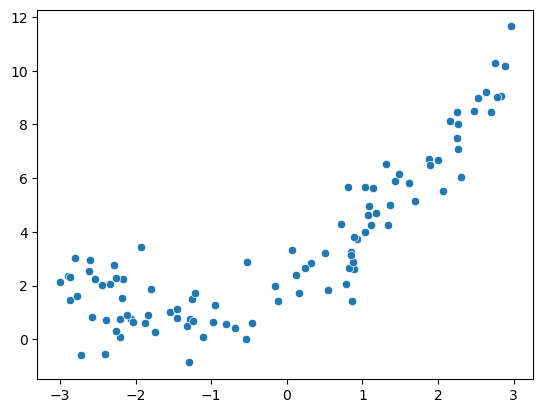

In [3]:
sns.scatterplot(x=X.flatten(), y=y.flatten())

In [4]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Simple Linear Regression

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [6]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


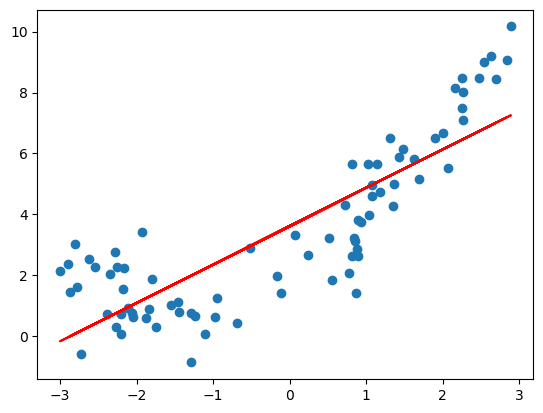

In [7]:
## Plot Training data plot best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train), color='r')

In [8]:
y_pred = lr.predict(X_test)
print(y_pred)

[[ 5.74489862e-01]
 [ 6.51283789e+00]
 [ 3.03136765e+00]
 [ 4.00655466e+00]
 [ 2.59415515e+00]
 [ 7.34772458e+00]
 [ 3.81826635e+00]
 [-1.80579961e-03]
 [ 5.98230577e+00]
 [ 5.30377580e-01]
 [ 3.62178649e-01]
 [ 1.94820670e+00]
 [ 7.07930723e+00]
 [ 5.00863735e+00]
 [ 3.75724587e+00]
 [ 3.35751598e-01]
 [ 2.08019207e+00]
 [ 7.10788322e+00]
 [ 2.03037066e+00]
 [ 2.92190761e+00]]


In [9]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

## R2 Score
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(f"R2 score: {score}")

## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]
adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(f"Adjusted R2 score: {adjusted_score}")

Mean Squared Error: 3.9078440552773728
Mean Absolute Error: 1.6844168719024204
Root Mean Squared Error: 1.9768267641038688
R2 score: 0.6714694564237753
Adjusted R2 score: 0.6532177595584294


## Simple Polynomial Regression

In [10]:
## apply polynomial transformation with degree=2
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=True)

In [11]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = lr.predict(X_test_poly)

In [14]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

## R2 Score
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(f"R2 score: {score}")

## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]
adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(f"Adjusted R2 score: {adjusted_score}")

Mean Squared Error: 0.8571949938730874
Mean Absolute Error: 0.7707554687321189
Root Mean Squared Error: 0.9258482563968501
R2 score: 0.9279360349838843
Adjusted R2 score: 0.9239324813718779


In [15]:
print(lr.coef_)

[[0.         1.41707298 0.47181405]]


In [16]:
print(lr.intercept_)

[2.0763242]


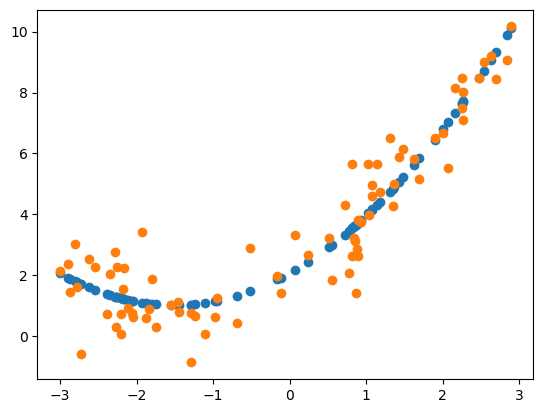

In [17]:
plt.scatter(x=X_train, y=lr.predict(X_train_poly))
plt.scatter(x=X_train, y=y_train)

In [18]:
## apply polynomial transformation with degree=2
poly2 = PolynomialFeatures(degree=3, include_bias=True)

X_train_poly = poly2.fit_transform(X_train)
X_test_poly = poly2.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred = lr.predict(X_test_poly)

## Performance Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

## R2 Score
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(f"R2 score: {score}")

## Adjusted R2 Score
n = len(y_test)
k = X_test.shape[1]
adjusted_score = 1 - (((1-score)*(n-1))/(n-k-1))
print(f"Adjusted R2 score: {adjusted_score}")

Mean Squared Error: 0.8730846666994916
Mean Absolute Error: 0.7629667368060342
Root Mean Squared Error: 0.9343899971101423
R2 score: 0.9266001979399632
Adjusted R2 score: 0.92252243115885


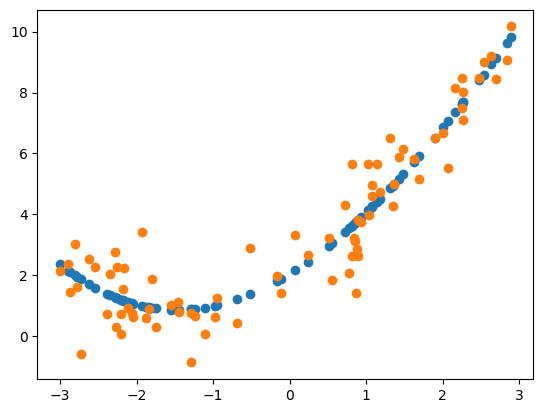

In [19]:
plt.scatter(x=X_train, y=lr.predict(X_train_poly))
plt.scatter(x=X_train, y=y_train)

In [20]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

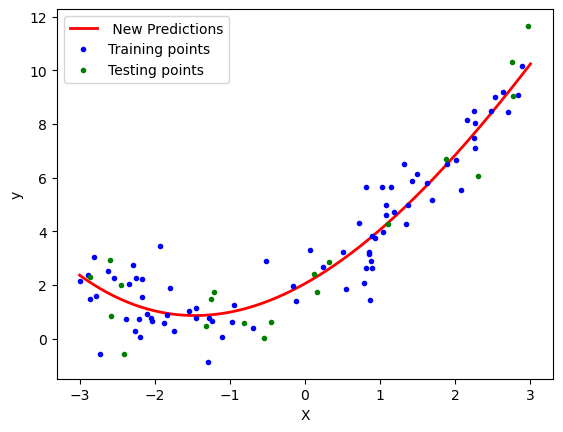

In [21]:
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_new = lr.predict(poly2.transform(X_new))
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts

In [22]:
from sklearn.pipeline import Pipeline

In [23]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

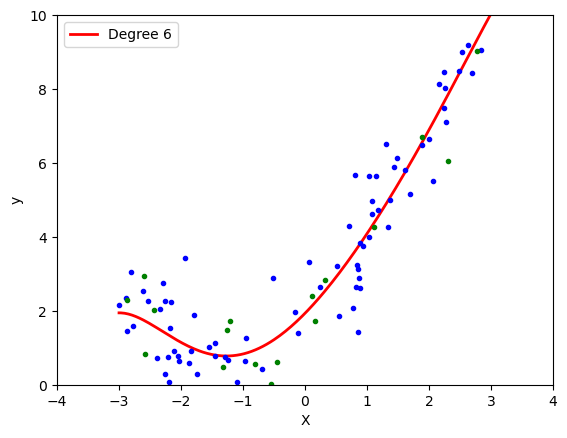

In [27]:
poly_regression(6)